## 1. Import data 

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [2]:
t_eval = np.load('data/t_eval.npy', allow_pickle = True)
returns = pd.read_csv('data/returns.csv', index_col = 0, parse_dates = True)

print(len(t_eval))
returns


83


,AAPL,ABBV,AEP,AMT,AMZN,APD,AVGO,BAC,BLK,CAT,...,SLB,SO,SPG,T,TSLA,UNH,UNP,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2013-02-01,-0.025611,0.006249,0.043118,0.018863,-0.004644,-0.012546,-0.044299,-0.007083,0.014579,-0.063137,...,0.001280,0.017481,-0.001216,0.031686,-0.074129,-0.032397,0.047275,0.007152,0.011795,0.001689
2013-03-01,0.002850,0.099438,0.038571,-0.008802,0.008365,0.017102,0.053786,0.081207,0.076000,-0.060239,...,-0.038763,0.041559,-0.001890,0.021488,0.084208,0.071856,0.037927,0.053017,0.062073,0.006234
2013-04-01,0.000271,0.130748,0.055981,0.091278,-0.048751,-0.001838,-0.116809,0.010616,0.036765,-0.020399,...,-0.006161,0.027537,0.116043,0.036565,0.354112,0.046448,0.038232,0.026412,0.037894,-0.012507
2013-05-01,0.022172,-0.075763,-0.105860,-0.076042,0.058869,0.082198,0.165970,0.104060,0.046554,0.013258,...,-0.018989,-0.083413,-0.061104,-0.068211,0.593717,0.044068,0.048412,0.073319,-0.031781,0.023388
2013-06-01,-0.125896,-0.032134,-0.022959,-0.058244,0.031051,-0.023130,-0.003466,-0.059601,-0.077124,-0.039342,...,-0.014642,0.005225,-0.052546,0.011649,0.093672,0.048897,-0.002202,0.017600,-0.004687,-0.001327
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.031841,0.057611,0.030791,0.016470,-0.046413,0.055293,0.013231,0.010856,0.028467,0.028195,...,-0.093262,0.042178,0.086778,0.033208,-0.080549,0.024076,0.042541,-0.007159,0.120759,0.002523
2024-09-01,0.017316,0.005942,0.022872,0.037234,0.042931,0.065547,0.061035,-0.020110,0.057443,0.093803,...,-0.040960,0.042820,0.022470,0.100323,0.200441,-0.005857,-0.038248,-0.034450,0.044570,-0.006123
2024-10-01,-0.030902,0.039799,-0.038247,-0.078075,0.000376,0.048023,-0.015953,0.052527,0.032657,-0.035307,...,-0.045851,0.009381,0.000592,0.037007,-0.046071,-0.035124,-0.060242,0.139092,0.014751,-0.003761


## 2. PCA and Covariance Estimation

In [3]:
from sklearn.decomposition import PCA

lookback = 36
window = returns.iloc[-lookback-1:-1]
pca = PCA()
pca.fit(window)
variance_pct = pca.explained_variance_ratio_
cum_var = np.cumsum(variance_pct)
k = np.argmax(cum_var >= 0.8) + 1

Text(0.5, 1.0, 'Cross-Sectional Cumulative Variance')

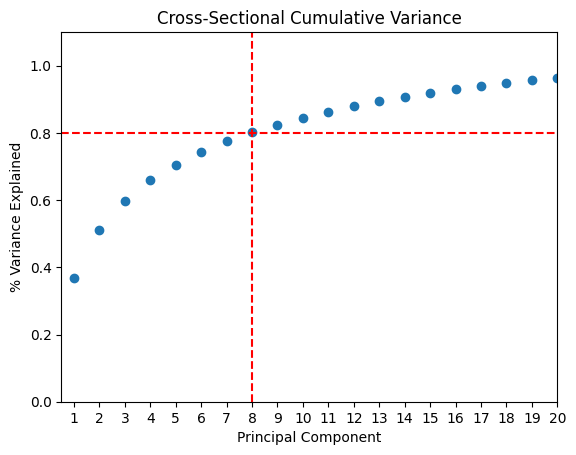

In [4]:

plt.scatter(range(1, 1 + len(cum_var)), cum_var)
plt.axhline(0.8, color = 'r', ls = '--')
plt.axvline(k, color = 'r', ls = '--')
plt.xlim(0.5,20)
plt.ylim(0,1.1)
plt.xticks(np.linspace(1,20,20))
plt.xlabel('Principal Component')
plt.ylabel('% Variance Explained')
plt.title('Cross-Sectional Cumulative Variance')



In [5]:
lookback = 36
threshold = 0.8
sigma_list = []

for t in range(lookback, len(returns)):
    # Lookback window
    window = returns.iloc[t-lookback:t]
    print(returns.index[t])
    # PCA deconstruction
    pca = PCA()
    pca.fit(window)

    cum_var = np.cumsum(pca.explained_variance_ratio_)
    k = np.argmax(cum_var >= threshold)

    B = pca.components_[:k,:]
    F = np.diag(pca.explained_variance_[:k])

    sigma_pca = B.T @ F @ B

    sample_cov = window.cov().values

    D = np.diag(np.diag(sample_cov - sigma_pca))

    sigma_t = sigma_pca + D

    sigma_list.append(sigma_t)

# Stack along axis 2
sigma = np.stack(sigma_list, axis=2)
sigma


2016-02-01 00:00:00
2016-03-01 00:00:00
2016-04-01 00:00:00
2016-05-01 00:00:00
2016-06-01 00:00:00
2016-07-01 00:00:00
2016-08-01 00:00:00
2016-09-01 00:00:00
2016-10-01 00:00:00
2016-11-01 00:00:00
2016-12-01 00:00:00
2017-01-01 00:00:00
2017-02-01 00:00:00
2017-03-01 00:00:00
2017-04-01 00:00:00
2017-05-01 00:00:00
2017-06-01 00:00:00
2017-07-01 00:00:00
2017-08-01 00:00:00
2017-09-01 00:00:00
2017-10-01 00:00:00
2017-11-01 00:00:00
2017-12-01 00:00:00
2018-01-01 00:00:00
2018-02-01 00:00:00
2018-03-01 00:00:00
2018-04-01 00:00:00
2018-05-01 00:00:00
2018-06-01 00:00:00
2018-07-01 00:00:00
2018-08-01 00:00:00
2018-09-01 00:00:00
2018-10-01 00:00:00
2018-11-01 00:00:00
2018-12-01 00:00:00
2019-01-01 00:00:00
2019-02-01 00:00:00
2019-03-01 00:00:00
2019-04-01 00:00:00
2019-05-01 00:00:00
2019-06-01 00:00:00
2019-07-01 00:00:00
2019-08-01 00:00:00
2019-09-01 00:00:00
2019-10-01 00:00:00
2019-11-01 00:00:00
2019-12-01 00:00:00
2020-01-01 00:00:00
2020-02-01 00:00:00
2020-03-01 00:00:00


array([[[ 4.49803637e-03,  4.46091067e-03,  4.76867895e-03, ...,
          5.84733882e-03,  5.84756186e-03,  5.66656778e-03],
        [ 1.68576087e-03,  1.72321516e-03,  1.83038455e-03, ...,
          9.59711488e-04,  8.34915348e-04,  6.78643876e-04],
        [-7.57089931e-06,  7.12397379e-05,  2.62991052e-04, ...,
          1.63598599e-03,  1.64256686e-03,  1.63832314e-03],
        ...,
        [ 1.06331114e-03,  1.03515770e-03,  1.09519709e-03, ...,
          2.33819863e-03,  2.01616723e-03,  2.46173643e-03],
        [-1.92017498e-04, -1.28282108e-04, -3.22673247e-05, ...,
          1.89045625e-03,  1.81774626e-03,  2.01748925e-03],
        [ 1.29510988e-03,  1.26380397e-03,  1.41305316e-03, ...,
          6.63321965e-04,  5.07577389e-04,  5.94051570e-04]],

       [[ 1.68576087e-03,  1.72321516e-03,  1.83038455e-03, ...,
          9.59711488e-04,  8.34915348e-04,  6.78643876e-04],
        [ 4.78218422e-03,  4.79101704e-03,  4.60652190e-03, ...,
          4.18651526e-03,  4.11615530e

## 3. Risk-Adjusted Alpha Allocation

In [6]:
def standardise(df: pd.DataFrame) -> pd.DataFrame:
    def standardise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return df.apply(standardise_row, axis=1)

def normalise(df: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        tot = row.abs().sum()
        return row / tot

    return df.apply(normalise_row, axis=1)

In [7]:
scores = pd.read_csv('data/factor_scores.csv', index_col = 0, parse_dates = True)
scores_n = normalise(scores)
scores_n

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.011176,0.006809,0.099154,0.020493,0.016893,0.010840,0.019812,0.010589,0.017258,0.012424,...,-0.009055,-0.001124,0.002427,-0.018082,-0.020567,-0.006260,-0.009322,-0.010531,0.061620,0.013870
2018-02-01,-0.001332,0.002496,0.106148,0.013165,0.011541,0.007301,0.013622,0.003435,0.011804,0.012026,...,-0.003996,-0.000838,0.014152,-0.019394,-0.026306,-0.002466,-0.008043,-0.006270,0.047577,0.012337
2018-03-01,-0.008362,0.010814,0.115377,0.003716,0.000276,0.010545,0.021025,-0.000079,0.009354,0.006587,...,0.000550,-0.004701,0.021447,-0.021850,-0.025081,-0.007061,-0.015106,-0.011106,0.027155,0.005040
2018-04-01,0.000419,0.011713,0.108762,0.002334,-0.000500,0.008435,0.018310,-0.001968,0.007375,0.005041,...,-0.007026,-0.004922,0.010520,-0.023973,-0.029930,-0.008083,-0.019211,-0.009619,0.038767,0.003030
2018-05-01,0.009626,0.006441,0.083229,0.008728,-0.003789,0.003311,0.014424,-0.006418,0.002935,0.000121,...,-0.005145,-0.005047,0.008196,-0.024623,-0.030043,-0.010538,-0.022397,-0.015070,0.041862,0.002396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,-0.003234,0.001312,0.082591,0.042968,0.007770,-0.003032,-0.002741,-0.000799,0.008526,-0.011356,...,0.013293,0.003179,-0.015212,-0.002827,-0.004776,-0.018097,-0.027817,0.025436,0.016362,0.007738
2024-08-01,0.002791,0.002921,0.080218,0.037955,0.022614,-0.015285,-0.010571,-0.009766,0.007521,0.001137,...,0.029066,0.013465,-0.004855,-0.005136,0.013359,-0.020036,-0.019886,0.025763,0.015596,0.014646
2024-09-01,0.009946,0.011953,0.085875,0.046073,0.015050,0.001910,-0.010154,-0.002345,0.005214,-0.004270,...,0.019944,0.002217,-0.012632,-0.010269,0.005188,-0.016785,-0.021704,0.017630,0.011428,0.009922


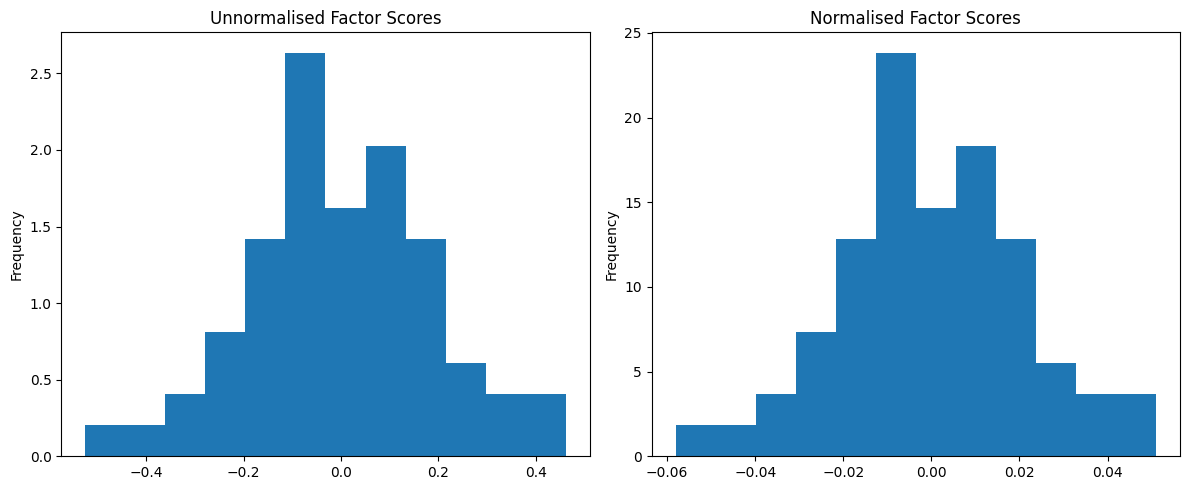

In [8]:
fig, ax = plt.subplots(1, 2, figsize = (12,5))
scores.iloc[60].plot(ax = ax[0], kind = 'hist', bins = 12, density = True)
scores_n.iloc[60].plot(ax = ax[1], kind = 'hist', bins = 12, density = True)
ax[0].set_title('Unnormalised Factor Scores')
ax[1].set_title('Normalised Factor Scores')
plt.tight_layout()

In [9]:
t_eval = scores.index
sigma_t = sigma[:,:,-len(t_eval):]
sigma_t.shape

(60, 60, 83)

In [10]:
weights_t = pd.DataFrame(
    index = t_eval, 
    columns = scores.columns
)
for i,t in enumerate(t_eval):
    mu_t = scores_n.loc[t].values
    sigma_t_i = sigma[:,:,i]

    w = np.linalg.solve(sigma_t_i, mu_t)
    w = w - w.mean() # denorm
    w = w / np.abs(w).sum() # scale exposure

    weights_t.loc[t] = w

print(weights_t.sum(axis = 1))
print(weights_t.abs().sum(axis = 1))


Date
2018-01-01    0.0
2018-02-01    0.0
2018-03-01   -0.0
2018-04-01    0.0
2018-05-01    0.0
             ... 
2024-07-01   -0.0
2024-08-01   -0.0
2024-09-01    0.0
2024-10-01    0.0
2024-11-01   -0.0
Length: 83, dtype: object
Date
2018-01-01    1.0
2018-02-01    1.0
2018-03-01    1.0
2018-04-01    1.0
2018-05-01    1.0
             ... 
2024-07-01    1.0
2024-08-01    1.0
2024-09-01    1.0
2024-10-01    1.0
2024-11-01    1.0
Length: 83, dtype: object


In [11]:
# Calculate Risk-adjusted Returns
returns_eval = pd.read_csv('data/returns_eval.csv', index_col = 0, parse_dates = True)

ra_returns = (returns_eval * weights_t).sum(axis = 1)
ra_returns.to_csv('outputs/ra_returns.csv')

## 4. Mean-Variance Optimisation

In [12]:
import cvxpy as cp

In [13]:
assets = scores.columns
n = len(assets)
mvo = {}
lams = np.arange(1,50,1)

for lam in lams:

    weights_mvo = pd.DataFrame(index=t_eval, columns=assets)

    for i, t in enumerate(t_eval):

        mu = scores_n.loc[t].values
        Sigma = sigma_t[:, :, i]

        w_mvo = cp.Variable(n)

        objective = cp.Maximize(
            mu @ w_mvo - 0.5 * lam * cp.quad_form(w_mvo, Sigma)
        )

        constraints = [
            cp.sum(w_mvo) == 0,          # market neutral
            cp.norm1(w_mvo) <= 1         # leverage constraint
        ]

        prob = cp.Problem(objective, constraints)
        prob.solve(solver=cp.OSQP)

        weights_mvo.loc[t] = w_mvo.value

    #print(weights_mvo.abs().sum(axis = 1))
    #print(weights_mvo.sum(axis = 1))

    mvo[lam] = weights_mvo

mvo.keys()

C:\Users\godwi\AppData\Local\Temp\ipykernel_29428\388548118.py:27: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=cp.OSQP)


dict_keys([np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49)])

In [14]:
mvo_returns = {}
for lam in lams:
    mvo_returns[lam] = (returns_eval * mvo[lam]).sum(axis = 1)

np.save('outputs/mvo_returns_lambda.npy', mvo_returns)

## 5. Plots